## Video Game Sales

### Requirements   
We are required to use the dataset contained within the file **“vgsales.csv”** and then answer the following questions using a different visualization type (eg. Bar Chart, Scatter graph etc…) for each question: 
 
•	What are the top 5 games by global sales?   
•	What is the distribution of the most popular 4 game genres?  
•	Do older games (2006 and earlier) have a higher MEDIAN “eu_sales” than newer games (after 2006)?  
•	What are the 3 most common “developer” in the dataset?  

### We must incorporate the following elements:
A Jupyter Notebook detailing your 
EDA process, 
Data Cleaning,
Feature Selection
Data Visualizations


In [3]:
# installing necessary libraries
!pip install pandas seaborn
!pip install plotly

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from numpy import median


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Appendix: installing libraries with pip in Jupyter Notebook — source: Visualizing_Data_start.ipynb — cell 1
import sys
!{sys.executable} -m pip install pandas seaborn
!{sys.executable} -m pip install plotly


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# loading the dataset and displaying the first few rows
df = pd.read_csv('../DATASETS/vgsales.csv')
df.head(10)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0,Nintendo,E
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# displaying the last few (2) rows of the dataset
df.tail(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.0,0.00,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16718,Winning Post 8 2016,PSV,2016.0,Simulation,Tecmo Koei,0.00,0.0,0.01,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# -- SECTION EDA (Exploratory Data Analysis) --
# basic information about the dataset

df.shape          # volume of data
df.info()         # data types and non-null counts
df.describe()     # statistics
df.isnull().sum() # missing values

<class 'pandas.core.frame.DataFrame'>
Index: 6825 entries, 0 to 16706
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             6825 non-null   object 
 1   Platform         6825 non-null   object 
 2   Year_of_Release  6825 non-null   int64  
 3   Genre            6825 non-null   object 
 4   Publisher        6825 non-null   object 
 5   NA_Sales         6825 non-null   float64
 6   EU_Sales         6825 non-null   float64
 7   JP_Sales         6825 non-null   float64
 8   Other_Sales      6825 non-null   float64
 9   Global_Sales     6825 non-null   float64
 10  Critic_Score     6825 non-null   float64
 11  Critic_Count     6825 non-null   float64
 12  User_Score       6825 non-null   object 
 13  User_Count       6825 non-null   float64
 14  Developer        6825 non-null   object 
 15  Rating           6825 non-null   object 
dtypes: float64(8), int64(1), object(7)
memory usage: 906.4+ KB


Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64

<small>
We can see important columns:

- name
- platform
- year_of_release
- genre
- eu_sales
- global_sales
- developer

but also how many rows have missing data (all NOT NULL Columns)
</small>

In [4]:
# data cleaning
df.dropna(inplace=True) # removing rows with missing values 
df['Year_of_Release'] = df['Year_of_Release'].astype(int) # converting year to integer
df.drop_duplicates(inplace=True) # removing duplicate entries

# check data types and non-null counts after cleaning
df.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 6825 entries, 0 to 16706
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             6825 non-null   object 
 1   Platform         6825 non-null   object 
 2   Year_of_Release  6825 non-null   int64  
 3   Genre            6825 non-null   object 
 4   Publisher        6825 non-null   object 
 5   NA_Sales         6825 non-null   float64
 6   EU_Sales         6825 non-null   float64
 7   JP_Sales         6825 non-null   float64
 8   Other_Sales      6825 non-null   float64
 9   Global_Sales     6825 non-null   float64
 10  Critic_Score     6825 non-null   float64
 11  Critic_Count     6825 non-null   float64
 12  User_Score       6825 non-null   object 
 13  User_Count       6825 non-null   float64
 14  Developer        6825 non-null   object 
 15  Rating           6825 non-null   object 
dtypes: float64(8), int64(1), object(7)
memory usage: 906.4+ KB


In [5]:
# statistics after cleaning
df.describe() 

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000
mean,2007.436777,0.394484,0.236089,0.064158,0.082677,0.777590,70.272088,28.931136,174.722344
std,4.211248,0.967385,0.687330,0.287570,0.269871,1.963443,13.868572,19.224165,587.428538
min,1985.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2004.000000,0.060000,0.020000,0.000000,0.010000,0.110000,62.000000,14.000000,11.000000
50%,2007.000000,0.150000,0.060000,0.000000,0.020000,0.290000,72.000000,25.000000,27.000000
75%,2011.000000,0.390000,0.210000,0.010000,0.070000,0.750000,80.000000,39.000000,89.000000
max,2016.000000,41.360000,28.960000,6.500000,10.570000,82.530000,98.000000,113.000000,10665.000000



References:

<small>

df.dropna()   -   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html

df.astype()  -   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html

df.drop_duplicates()  -   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html

</small>

In [7]:
# selecting relevant columns for analysis

columns = ['Name','Genre','Year_of_Release','EU_Sales','Global_Sales','Developer']

df_selection = df[columns].copy()
df_selection.info() 

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Genre            16717 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   EU_Sales         16719 non-null  float64
 4   Global_Sales     16719 non-null  float64
 5   Developer        10096 non-null  str    
dtypes: float64(3), str(3)
memory usage: 783.8 KB


## Data Visualizations 1 -  Top 5 Games

**References: handout-beginner.pdf**


### plt.subplots() creates a figure and a set of sublots.
fig, ax = plt.subplots()

### creating a horizontal bar chart of the top 5 games by global sales
ax.barh(top5['Name'], top5['Global_Sales'], color='skyblue')

### adding title and labels to the chart
ax.set_title('Top 5 Games by global sales')
ax.set_xlabel('Global Sales')
ax.set_ylabel('Game Title')

**References: handout-tips.pdf**
plt.tight_layout()   
plt.show()

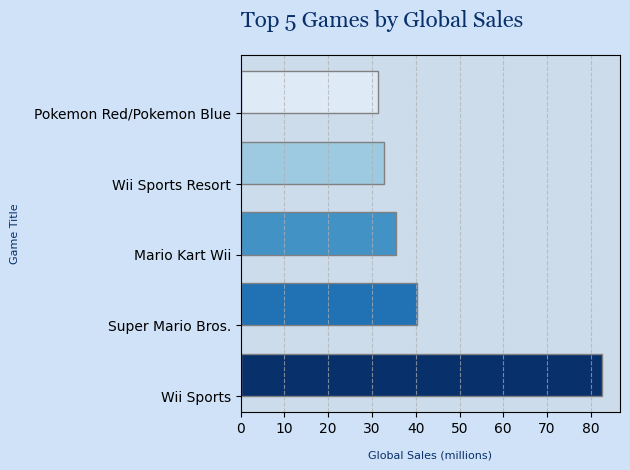

<Figure size 640x480 with 0 Axes>

In [49]:
# My preparing data — sort by Global_Sales to get the highest selling games, take only top 5
top5 = df_selection.sort_values(by='Global_Sales', ascending=False).head(5)

# create figure and axes object
fig, ax = plt.subplots()

# different shades of blue for each bar - 
colors = ['#08306b', '#2171b5', '#4292c6', '#9ecae1', '#deebf7']

# barh because horizontal bars are easier to read with long game titles
ax.barh(top5['Name'], top5['Global_Sales'], color=colors, edgecolor='grey', height=0.6, align='edge', label='Global Sales', )
ax.set_title('Top 5 Games by Global Sales', fontsize=16, fontfamily='Georgia', pad=20, color='#08306b', zorder=4, loc='left')
ax.set_xlabel('Global Sales (millions)', fontsize=8, labelpad=10, color='#08306b')
ax.set_ylabel (('Game Title'), fontsize=8, labelpad=10, color='#08306b')

# APPENDIX: adding grid for better readability
ax.grid(axis='x', linestyle='--', alpha=0.7, zorder=0)

# APPENDIX: Background color
fig.patch.set_facecolor("#82B3EC5F")   # jasny błękit
ax.set_facecolor("#cddceb")

# fit everything nicely and display the plot
plt.tight_layout()
plt.show()



# save the plot with high resolution for better quality
plt.savefig('top5_games.png', dpi=300)

## Data Visualizations 2 - Top 4 Game Genres

**References: matplotlib.org/stable/tutorials/lifecycle.html**
fig, ax = plt.subplots()

### plt.subplots() creates a figure and a set of sublots.
fig, ax = plt.subplots()

### Preparation of the vertical bar chart
ax.bar(top4genres.index, top4genres.values, color='steelblue', edgecolor='black')
ax.set_title('Distribution of Top 4 Game Genres')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Games')

plt.tight_layout()
plt.show()

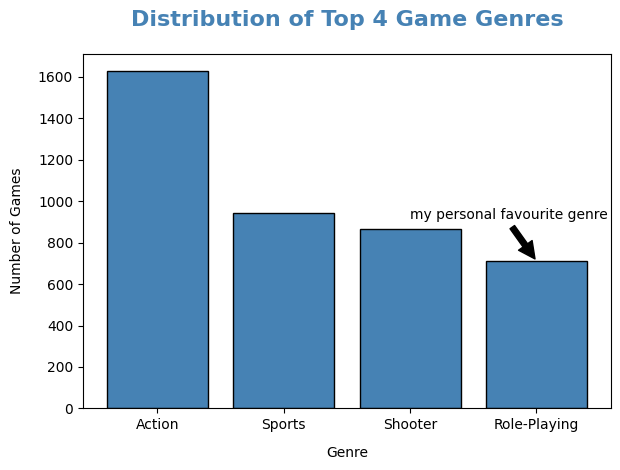

<Figure size 640x480 with 0 Axes>

In [33]:
# My preparing data — count how many games are in each genre, keep only top 4
top4genres = df_selection['Genre'].value_counts().head(4)

# create figure and axes object
fig, ax = plt.subplots()

# ax.barh() replaced with ax.bar() — vertical bars work better here since genre names are short
ax.bar(top4genres.index, top4genres.values, color='steelblue', edgecolor='black')

# add title and labels so the chart is clear and informative
ax.set_title('Distribution of Top 4 Game Genres', fontsize=16, fontweight='bold', pad=20, color='steelblue')
ax.set_xlabel('Genre', fontsize=10, labelpad=10)
ax.set_ylabel('Number of Games', fontsize=10, labelpad=10)

# personal note on Role-Playing bar — source: Visualizing_Data_start.ipynb cell 37
ax.annotate('my personal favourite genre',
            xy=(3, top4genres['Role-Playing']),
            xytext=(2, top4genres['Role-Playing'] + 200),
            arrowprops=dict(facecolor='black', shrink=0.05),)

plt.tight_layout()
plt.show()

plt.savefig('top4_genres.png', dpi=300)


## Data Visualizations 3 - Mediana Older vs Never Games

**References: Visualizing_Data_start.ipynb — cell 30**
fig, ax = plt.subplots
ax = sns.barplot(x='Era', y='EU_Sales', data=df_selection, estimator=median)

### Preparation of the vertical bar chart
ax.set_title('Median EU Sales: Older vs Newer Games')
ax.set_xlabel('Timeframe')
ax.set_ylabel('Median EU Sales (millions)')

### adding data labels to the bars
plt.tight_layout()
plt.show()

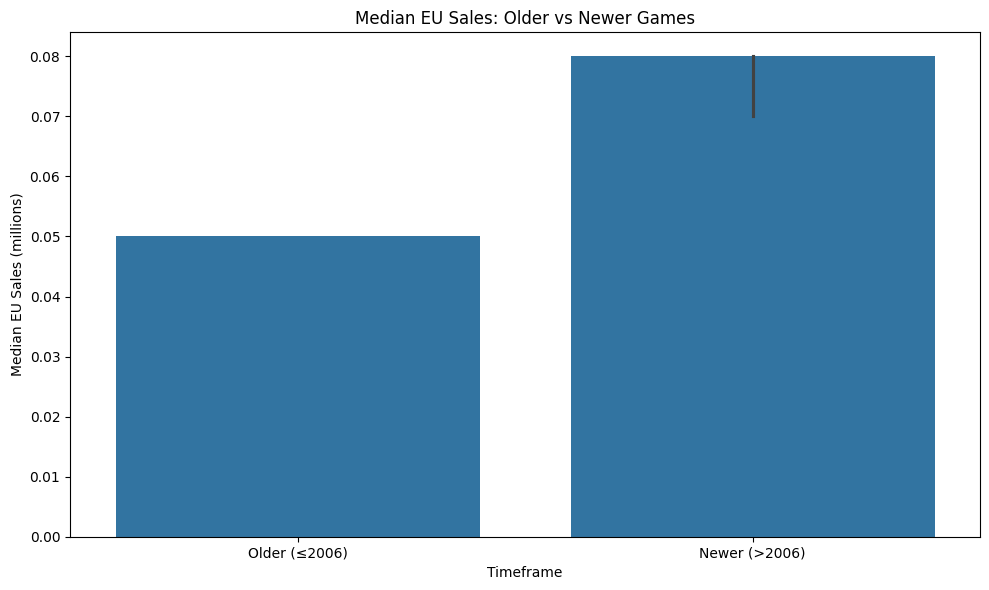

In [ ]:

# Create figure and axes with a bigger size so the chart is easy to read
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# barplot with median estimator to compare older vs newer games, source: Visualizing_Data_start.ipynb — cell 30
ax = sns.barplot(x='Era', y='EU_Sales', data=df_selection, estimator=median)

# add title and labels to make the chart self-explanatory
ax.set_title('Median EU Sales: Older vs Newer Games')
ax.set_xlabel('Timeframe')
ax.set_ylabel('Median EU Sales (millions)')

# fit everything nicely and display the plot
plt.tight_layout()
plt.show()

## Data Visualizations 4 - Top 3 Developers

**References: Visualizing_Data_start.ipynb — cell 29**

top3names = df_selection['Developer'].value_counts().head(3).index.tolist()
df_top3 = df_selection[df_selection['Developer'].isin(top3names)]

sns.catplot(data=df_top3, x='Developer', aspect=1.5, kind="count", color="b")
plt.title('Top 3 Most Common Developers')

plt.tight_layout()
plt.show()

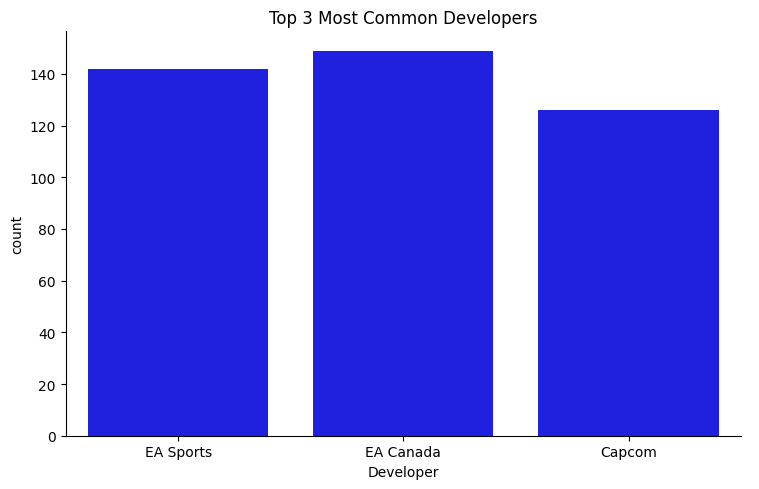

In [ ]:
# My: preparing data — get top 3 developer names, then filter df to keep only their rows
top3names = df_selection['Developer'].value_counts().head(3).index.tolist()
df_top3 = df_selection[df_selection['Developer'].isin(top3names)]

#  catplot with kind="count" counts rows per developer automatically ,source: Visualizing_Data_start.ipynb — cell 29
sns.catplot(data=df_top3, x='Developer', aspect=1.5, kind="count", color="b")
plt.title('Top 3 Most Common Developers')

# adding data labels to the bars
plt.tight_layout()
plt.show()

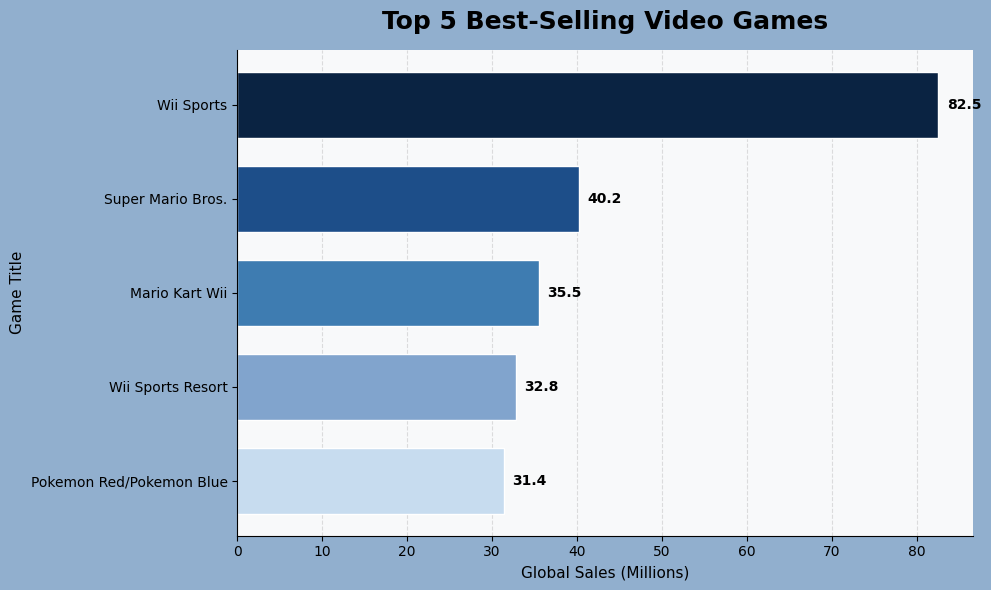

In [34]:
import matplotlib.pyplot as plt

# Top 5 games
top5 = (
    df_selection
    .sort_values(by='Global_Sales', ascending=False)
    .head(5)
)

# Figure
fig, ax = plt.subplots(figsize=(10, 6))

# Gradient blue palette
colors = ['#0A2342', '#1D4E89', '#3E7CB1', '#81A4CD', '#C7DCEF']

# Horizontal bars
bars = ax.barh(
    top5['Name'],
    top5['Global_Sales'],
    color=colors,
    edgecolor='white',
    height=0.7
)

# Highest value at the top
ax.invert_yaxis()

# Title and labels
ax.set_title(
    'Top 5 Best-Selling Video Games',
    fontsize=18,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Global Sales (Millions)', fontsize=11)
ax.set_ylabel('Game Title', fontsize=11)

# Grid
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

ax.set_axisbelow(True)

# Remove unnecessary spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add sales values to bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Background color
fig.patch.set_facecolor("#91afce")
ax.set_facecolor('#f8f9fa')

plt.tight_layout()

# Save BEFORE show
plt.savefig('top5_games_sales.png', dpi=300, bbox_inches='tight')

plt.show()